# Notebook 4: Hyperparameter Tuning & Calibration

Use **Optuna** to find the best XGBoost hyperparameters, then apply **Platt scaling** to make predicted probabilities reliable.

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import optuna

from sklearn.model_selection import train_test_split

from src.data_processing import TARGET_COL
from src.features import get_numeric_features
from src.models import xgboost_model, tune_xgboost, calibrate_model
from src.evaluation import evaluate_model, plot_roc_curves, plot_calibration, risk_band_summary

plt.rcParams['figure.dpi'] = 110

## 2. Load Data — Three-Way Split

We need three sets:
- **Train** — fit the model
- **Calibration** — fit Platt scaling (must be held out, not seen during training)
- **Test** — final evaluation

In [2]:
df = pd.read_parquet('../data/processed/features.parquet')
FEATURES = get_numeric_features(df)
X, y = df[FEATURES], df[TARGET_COL]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_calib, y_train, y_calib = train_test_split(X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=42)

print(f"Train:       {X_train.shape[0]:,} rows")
print(f"Calibration: {X_calib.shape[0]:,} rows")
print(f"Test:        {X_test.shape[0]:,} rows")
print(f"Default rate (test): {y_test.mean():.2%}")

Train:       108,364 rows
Calibration: 19,124 rows
Test:        22,498 rows
Default rate (test): 6.69%


## 3. Baseline XGBoost

In [3]:
baseline_xgb = xgboost_model()
baseline_xgb.fit(X_train, y_train)
baseline_prob = baseline_xgb.predict_proba(X_test)[:, 1]
baseline_metrics = evaluate_model(y_test, baseline_prob, 'XGBoost (baseline)')
print(baseline_metrics)

{'model': 'XGBoost (baseline)', 'roc_auc': 0.8745774026874953, 'avg_precision': 0.416249407619632, 'brier_score': 0.0817525972776394}


## 4. Hyperparameter Tuning with Optuna

Optuna runs 50 trials using Bayesian optimization — it learns from previous trials which parameter combinations are promising, focusing the search rather than sampling randomly.

In [4]:
print("Running Optuna search (50 trials x 5-fold CV)...")
best_xgb, study = tune_xgboost(X_train, y_train, n_trials=50, cv=5)
print("Done.")

Running Optuna search (50 trials x 5-fold CV)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best AUC (CV): 0.8637
Best params:   {'n_estimators': 474, 'max_depth': 4, 'learning_rate': 0.01770535874404442, 'subsample': 0.8035429496065427, 'colsample_bytree': 0.5726535947015929, 'min_child_weight': 5, 'gamma': 0.7218964156533173, 'reg_alpha': 0.45048578817553847, 'reg_lambda': 0.005070860247895224}
Done.


## 5. Optuna Results

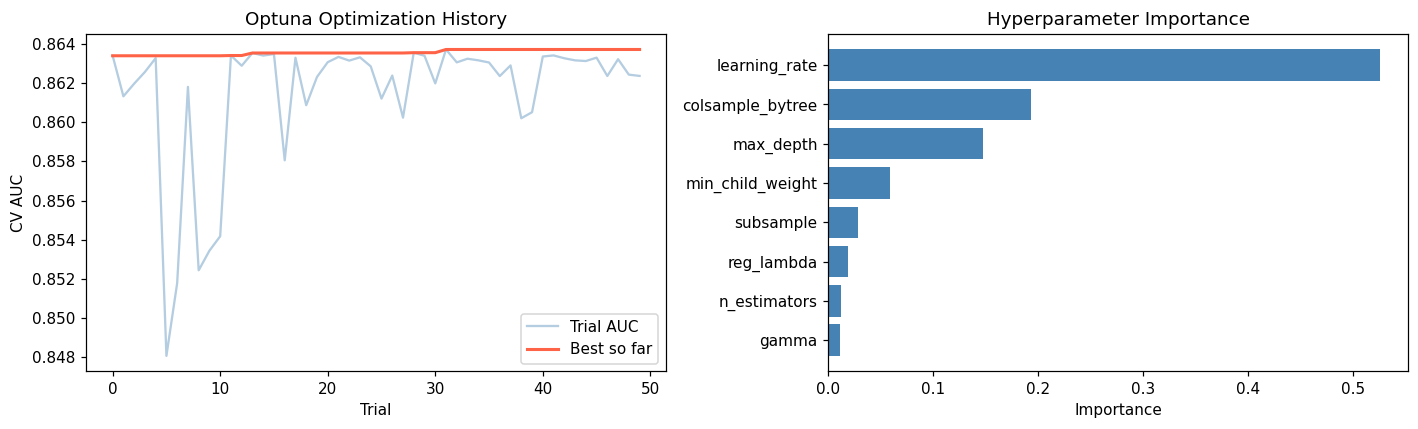

In [5]:
# Optimization history
trials_df = study.trials_dataframe()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(trials_df['number'], trials_df['value'], alpha=0.4, color='steelblue', label='Trial AUC')
axes[0].plot(trials_df['number'], trials_df['value'].cummax(), color='tomato', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV AUC')
axes[0].set_title('Optuna Optimization History')
axes[0].legend()

importances = optuna.importance.get_param_importances(study)
names = list(importances.keys())[:8]
vals  = [importances[n] for n in names]
axes[1].barh(names[::-1], vals[::-1], color='steelblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importance')

plt.tight_layout()
plt.savefig('../outputs/figures/optuna_results.png', bbox_inches='tight')
plt.show()

## 6. Train Best Model

In [6]:
best_xgb.fit(X_train, y_train)
tuned_prob = best_xgb.predict_proba(X_test)[:, 1]
tuned_metrics = evaluate_model(y_test, tuned_prob, 'XGBoost (tuned)')
print(tuned_metrics)

{'model': 'XGBoost (tuned)', 'roc_auc': 0.8741433405998472, 'avg_precision': 0.4142192305659724, 'brier_score': 0.14092642742300127}


## 7. Calibration with Platt Scaling

XGBoost is optimised to rank borrowers (AUC), not to output accurate probabilities. Platt scaling fits a logistic regression on top of the raw outputs using the held-out calibration set.

In [7]:
calibrated_xgb = calibrate_model(best_xgb, X_calib, y_calib)
calibrated_prob = calibrated_xgb.predict_proba(X_test)[:, 1]
calibrated_metrics = evaluate_model(y_test, calibrated_prob, 'XGBoost (tuned + calibrated)')
print(calibrated_metrics)

{'model': 'XGBoost (tuned + calibrated)', 'roc_auc': 0.8741433405998472, 'avg_precision': 0.4142192305659724, 'brier_score': 0.04875270324168762}


## 8. Full Comparison

In [8]:
results = pd.DataFrame([baseline_metrics, tuned_metrics, calibrated_metrics])
results = results.set_index('model').round(4)
print(results.to_string())

                              roc_auc  avg_precision  brier_score
model                                                            
XGBoost (baseline)             0.8746         0.4162       0.0818
XGBoost (tuned)                0.8741         0.4142       0.1409
XGBoost (tuned + calibrated)   0.8741         0.4142       0.0488


## 9. ROC Curves

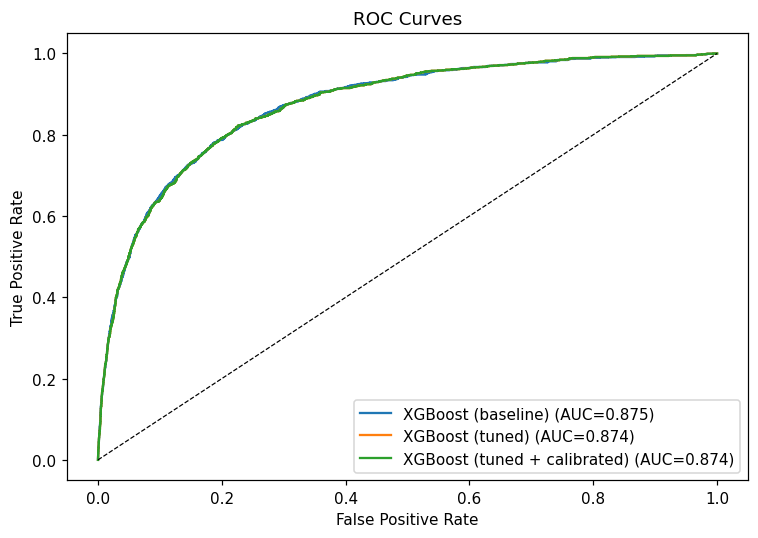

In [9]:
preds = {
    'XGBoost (baseline)':           baseline_prob,
    'XGBoost (tuned)':              tuned_prob,
    'XGBoost (tuned + calibrated)': calibrated_prob,
}
fig, ax = plt.subplots(figsize=(7, 5))
plot_roc_curves(preds, y_test, ax=ax)
plt.tight_layout()
plt.savefig('../outputs/figures/roc_tuned_vs_baseline.png', bbox_inches='tight')
plt.show()

## 10. Calibration Curves

A well-calibrated model follows the diagonal — predicted 20% should mean ~20% actually default. Platt scaling corrects systematic deviation.

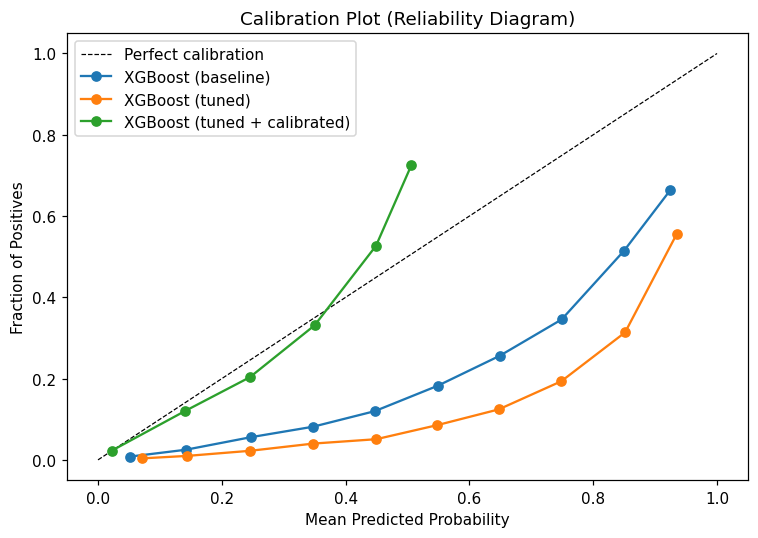

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_calibration(preds, y_test, n_bins=10, ax=ax)
plt.tight_layout()
plt.savefig('../outputs/figures/calibration_tuned_vs_baseline.png', bbox_inches='tight')
plt.show()

## 11. Risk Band Summary: Calibrated Model

In [11]:
summary = risk_band_summary(y_test, calibrated_prob)
print(summary.to_string(index=False))

risk_band  count  default_rate recommendation  pct_of_applicants
      Low  18288      0.022419        Approve          81.287226
   Medium   2234      0.133393  Manual Review           9.929772
     High   1976      0.402834        Decline           8.783003


/Users/ryanchang/claude/credit-default-risk/src/evaluation.py:82: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  return risk_band.map(mapping)


## 12. Save Models

In [12]:
os.makedirs('../outputs/models', exist_ok=True)
joblib.dump(best_xgb,       '../outputs/models/xgboost_tuned.pkl')
joblib.dump(calibrated_xgb, '../outputs/models/xgboost_tuned_calibrated.pkl')
joblib.dump(study,          '../outputs/models/optuna_study.pkl')
print("Saved.")

Saved.
